## Testing accuracy of quantics tensor trains for random functions

### Goal
See how well approximations of varying rank work for randomly generated functions.

### Method
Below we use two methods for generating random functions from their Fourier *cosine* series$^*$. Both generate random coefficients with a user-provided rate of decay. The first `rand_func1d_cos_basis_idct` uses the inverse discrete cosine transform. The second `rand_func_1d_cos_basis_bf` uses the naive brute-force method. I have implemented both because my first attempt, using the inverse discrete transform, was yielding unexpected results. 

### Results
So far, the expected pattern has not been observed with this method. For one, thing, extreme outliers are almost alway present. For another, the rank of the quantics approximation does not appear correlated with accuracy, at least not in a simple manner. 

My best guess at this point is that the extreme outliers are due to high peaks straddling boundaries in the quantics grid. 

$^*$ Note: I use the cosine series here because I haven't figured out how to set pivot rows correctly for the xfac python bindings. With the sine series values generated using the brute-force algorithm, the first entry is zero, which prevents the `QTensorCI` constructor from working correctly. 

In [1]:
import numpy as np
import scipy
import matplotlib.pyplot as plt
import xfacpy

In [2]:
rng = np.random.default_rng()

In [3]:
L = 10
N = 2**L

xs = np.linspace(0, 1, N, endpoint=False)

In [4]:
def rand_func1d_cos_basis_idct(k, L, rng):
    '''
    Use inverse discrete cosine transform
    '''
    N = 2**L
    a = rng.uniform(-0.5, 0.5, N)
    a /= np.linalg.norm(a)
    js = np.array([j**k for j in range(1, N + 1)], dtype=np.float64)

    coeff = a * js**(-1)

    f = scipy.fft.idct(coeff) * N
    return f

In [5]:
def rand_func1d_cos_basis_bf(k, L, rng):
    '''
    Use brute-force linear combination of cosines
    '''
    N = 2**L
    a = rng.uniform(-0.5, 0.5, N)
    a /= np.linalg.norm(a)
    js = np.array([j**k for j in range(1, N + 1)], dtype=np.float64)

    coeff = a * js**(-1)

    n = np.arange(N, dtype=np.float64)
    p = np.full(N, np.pi)
    xs = np.linspace(0, 1, N, endpoint=False)

    f = np.array([coeff @ np.cos(n * p * x) for x in xs])
    return f

In [6]:
# Helper functions to make it so that we can use our generated function data with the xfac QTensor API.

def coord_to_decimal_index(x, lb=0, ub=1, nBit=10):
    # convert a real coordinate to an index into the array
    # WARNING: This needs some error handling and check against NaNs, 0s, etc.
    return int((x - lb) * (2**nBit / (ub - lb)))

def make_callable(f_, lb=0, ub=1, nBit=10):
    def f(x):
        return f_[coord_to_decimal_index(x, lb, ub, nBit)]
    return f

def reconstruct(qtci, xs):
    return np.array([qtci.get_qtt().eval([x]) for x in xs])

In [7]:
def run_for_given_order(order, ranks, rng, gen, nRuns=100, nBit=10):
    l2_error = np.zeros((nRuns, ranks), dtype=np.float64)
    qtci_trueError = np.zeros((nRuns, ranks), dtype=np.float64)
    for rank in range(1, ranks + 1):
        for run in range(nRuns):
            xs = np.linspace(0, 1, 2**nBit, endpoint=False)
            
            f_ = gen(order, nBit, rng)
            f = make_callable(f_)
            
            qgrid = xfacpy.QuanticsGrid(a=0.0, b=1.0, nBit=nBit)
            args = xfacpy.TensorCI2Param()
            args.bondDim = rank
            
            qtci = xfacpy.QTensorCI(f1d=f, qgrid=qgrid, args=args)
            
            i = 0
            while not (qtci.isDone or i >= 10000):
                qtci.iterate()
                i += 1
            f_qtt = reconstruct(qtci, xs)
            error = np.linalg.norm(f_qtt - f_)
            l2_error[run][rank-1] = error
            qtci_trueError[run][rank-1] = qtci.trueError()
            
    return l2_error, qtci_trueError

## Test runs for orders 0-4

The below plots are intended for comparing behavior of the two methods of generating functions. They are not the final product for understanding the relationship between rate of decay and minimal rank. 

In [8]:
order0_l2_idct, order0_true_idct = run_for_given_order(0, 10, rng, rand_func1d_cos_basis_idct)
order0_l2_bf, order0_true_bf = run_for_given_order(0, 10, rng, rand_func1d_cos_basis_bf)

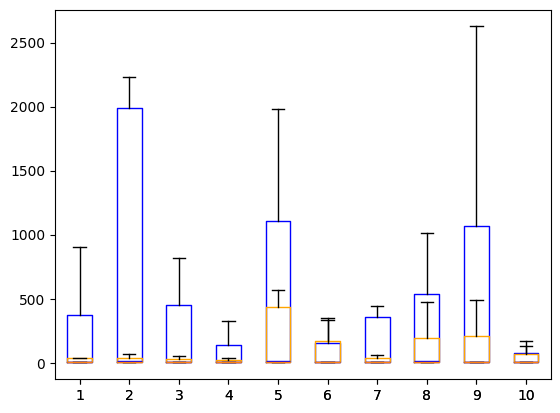

In [9]:
plt.boxplot(order0_true_idct, showfliers=False, boxprops=dict(color='blue'), medianprops=dict(color='blue'))
plt.boxplot(order0_true_bf, showfliers=False, boxprops=dict(color='orange'))
plt.show()

In [10]:
order1_l2_idct, order1_true_idct = run_for_given_order(1, 10, rng, rand_func1d_cos_basis_idct)
order1_l2_bf, order1_true_bf = run_for_given_order(1, 10, rng, rand_func1d_cos_basis_bf)

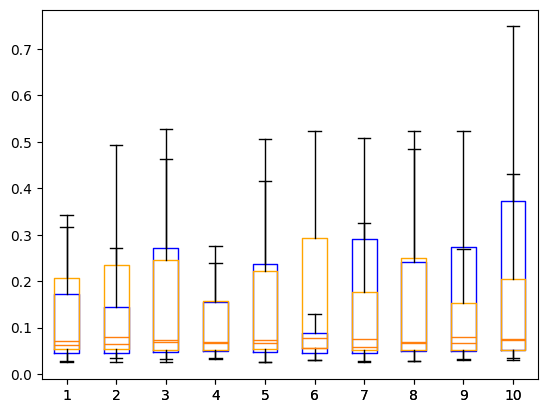

In [11]:
plt.boxplot(order1_true_idct, showfliers=False, boxprops=dict(color='blue'))
plt.boxplot(order1_true_bf, showfliers=False, boxprops=dict(color='orange'))
plt.show()

In [12]:
order2_l2_idct, order2_true_idct = run_for_given_order(2, L, rng, rand_func1d_cos_basis_idct)
order2_l2_bf, order2_true_bf = run_for_given_order(2, L, rng, rand_func1d_cos_basis_bf)

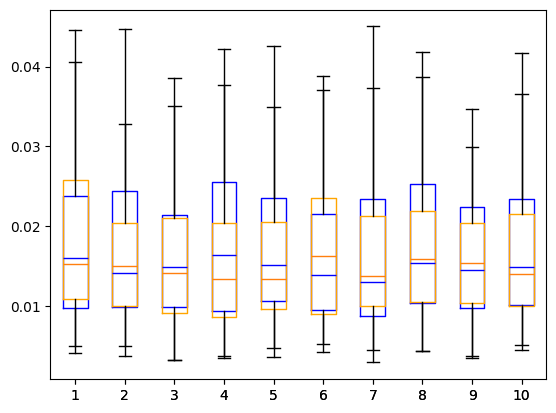

In [13]:
plt.boxplot(order2_true_idct, showfliers=False, boxprops=dict(color='blue'), medianprops=dict(color='blue'))
plt.boxplot(order2_true_bf, showfliers=False, boxprops=dict(color='orange'))
plt.show()

In [14]:
order3_l2_idct, order3_true_idct = run_for_given_order(3, L, rng, rand_func1d_cos_basis_idct)
order3_l2_bf, order3_true_bf = run_for_given_order(3, L, rng, rand_func1d_cos_basis_bf)

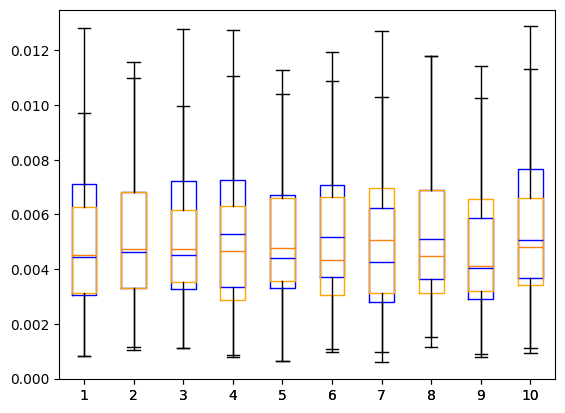

In [15]:
plt.boxplot(order3_true_idct, showfliers=False, boxprops=dict(color='blue'), medianprops=dict(color='blue'))
plt.boxplot(order3_true_bf, showfliers=False, boxprops=dict(color='orange'))
plt.show()

In [16]:
order4_l2_idct, order4_true_idct = run_for_given_order(4, L, rng, rand_func1d_cos_basis_idct)
order4_l2_bf, order4_true_bf = run_for_given_order(4, L, rng, rand_func1d_cos_basis_bf)

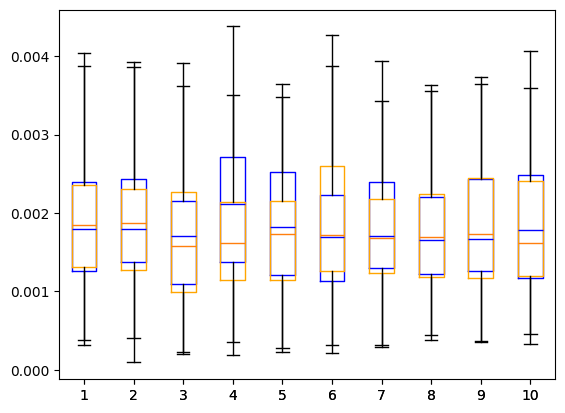

In [17]:
plt.boxplot(order4_true_idct, showfliers=False, boxprops=dict(color='blue'), medianprops=dict(color='blue'))
plt.boxplot(order4_true_bf, showfliers=False, boxprops=dict(color='orange'))
plt.show()